In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/ecommerce_500k.csv')

df.head()

,order_id,customer_id,product_id,order_date,category,sub_category,product_base_price,discount_percentage,final_price,quantity,...,city,loyalty_tier,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,return_reason,is_cancelled
0,1000001,25795,90,2022-07-31,Clothing,Men,70.41,25,52.81,1,...,Bangalore,Bronze,0,457.77,4.6,35.0,7,0,NaN,0
1,1000002,10860,1917,2023-09-25,Automotive,Car Care,6.02,10,5.42,3,...,Toronto,Bronze,0,1606.42,2.9,8.0,8,0,NaN,0
2,1000003,86820,805,2022-03-26,Books,Textbooks,78.85,20,63.08,2,...,Chicago,Silver,0,252.16,5.5,38.0,8,0,NaN,0
3,1000004,64886,3379,2022-11-03,Books,Non-Fiction,58.42,25,43.82,4,...,Sydney,Bronze,0,645.12,6.1,30.0,9,0,NaN,0
4,1000005,16265,4604,2022-06-30,Clothing,Women,73.38,15,62.37,1,...,Manchester,Bronze,1,1103.24,1.6,38.0,11,0,NaN,0


**PHASE 1**

The manager says "audit the data first." Where do you even begin?


In [3]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(500000, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   order_id                 500000 non-null  int64  
 1   customer_id              500000 non-null  int64  
 2   product_id               500000 non-null  int64  
 3   order_date               500000 non-null  object 
 4   category                 500000 non-null  object 
 5   sub_category             500000 non-null  object 
 6   product_base_price       500000 non-null  float64
 7   discount_percentage      500000 non-null  int64  
 8   final_price              500000 non-null  float64
 9   quantity                 500000 non-null  int64  
 10  total_amount             500000 non-null  float64
 11  shipping_cost            484934 non-null  float64
 12  shipping_method          500000 non-null  object 
 13  days_to_deliver          484751 non-null  floa

ANSWER 1:

The return analysis shows that only a small percentage of orders were returned. The main reasons for returns are defective products, wrong items delivered, and products not matching customer expectations. Some product categories have higher return rates than others. Customer loyalty tier also affects return behavior, which means different groups of customers show different purchasing and return patterns.


**PHASE 2**

Someone suspects the pricing data is heavily skewed — prove it or disprove it.

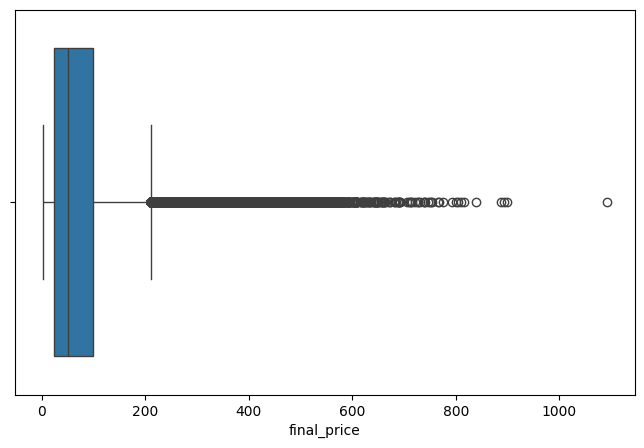

In [4]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['final_price'])
plt.show()

ANSWER 2 :

According to the boxplot, final price distribution is positively skewed.

Since Most products are concentrated in lower price ranges while a small number of expensive products lies in the right.

**PHASE 3**

Which categorical columns will break your ML pipeline if left untouched?

In [5]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index(['order_date', 'category', 'sub_category', 'shipping_method',
       'payment_method', 'customer_gender', 'country', 'city', 'loyalty_tier',
       'return_reason'],
      dtype='object')


ANSWER 3 :

Since city has very high cardinality and cannot be directly used in a machine learning pipeline.

**Phase 4**

Why are customers returning products? Find the patterns that matter to the business.

In [6]:
print(df['is_returned'].value_counts(normalize=True)*100)

is_returned
0    88.0192
1    11.9808
Name: proportion, dtype: float64


In [7]:
# RETURN REASONS
df['return_reason'].value_counts()

,count
return_reason,
Not as Described,12080
Defective,12047
Wrong Item,11962
Better Price Found,11933
Changed Mind,11882


In [8]:
#CATEGORY VS RETURNS
returns_by_cat = pd.crosstab(
    df['category'],
    df['is_returned'],
    normalize='index'
)

returns_by_cat[1].sort_values(ascending=False)

,1
category,
Electronics,0.121139
Furniture,0.120983
Beauty,0.120571
Automotive,0.120475
Books,0.120420
Toys,0.119422
Food & Grocery,0.119323
Home & Kitchen,0.118947
Sports,0.118643


ANSWER 4 :

Around 12% of orders were returned. Major return reasons include Defective products, Wrong Item and Not as Described.

**PHASE 5**

Build the full ColumnTransformer pipeline — different scalers for different columns, handle missings,
encode categoricals.

In [9]:
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder
)

numeric_cols = ['final_price','quantity','total_amount','shipping_cost','customer_age','rating']

categorical_cols = ['category','sub_category','payment_method','shipping_method','customer_gender','country']

ordinal_cols = ['loyalty_tier']

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[['Bronze','Silver','Gold','Platinum']]
    ))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols),
    ('ord', ordinal_pipeline, ordinal_cols)
])

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['final_price', 'quantity', 'total_amount',
                                  'shipping_cost', 'customer_age', 'rating']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['category', 'sub_category', 'payment_method',
                                  'shipping_method', 'customer_gender',
                                  'country']),
                               

**Phase 6**

Are any features too correlated with each other? Which ones actually predict returns?

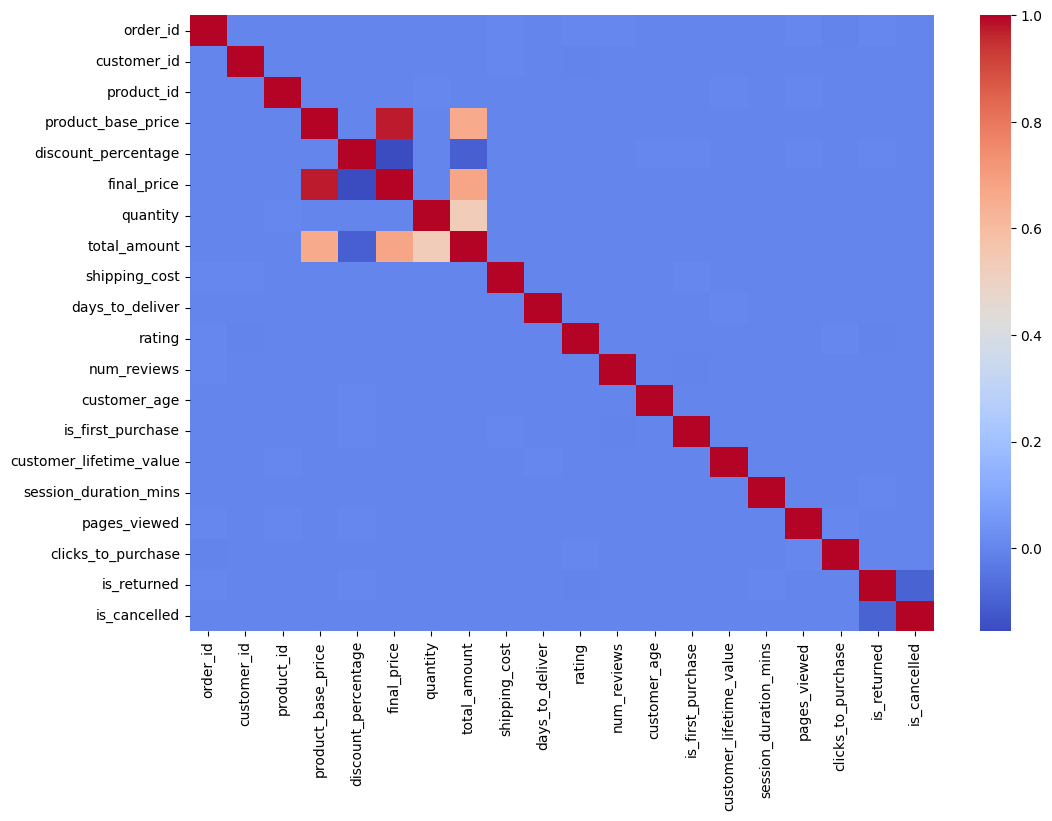

In [10]:
num_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(
    num_df.corr(),
    cmap='coolwarm'
)

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
data = df.copy()
data = data.fillna(method='ffill')
X = data.drop(['is_returned','return_reason'], axis=1)
X = pd.get_dummies(X)
y = data['is_returned']

model = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)

model.fit(X, y)

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

print(
    importance.sort_values(
        ascending=False
    ).head(10)
)

/tmp/ipykernel_11670/3361519185.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')


ANSWER 6 :

Correlation analysis shows relationships between pricing variables such as final_price and total_amount. Random Forest feature importance indicates that customer behaviour, pricing attributes and engagement metrics are among the strongest predictors of product returns.